# C2 · Taller 3 — Clustering jerárquico: ¿son reales los tipos de día de Shiro?

**Aprendizaje de Máquina · Universidad Sergio Arboleda · Semestre 26-2**
Grupo Shiro — Jose Leonardo Diazgranados, Sofía Londoño, Andrés Felipe Céspedes Rondón, Alex Duran
Docente: Hernán Darío Cruz Bueno · Sector: Energía y Medio Ambiente / IoT

---

## Qué componente de Shiro audita este taller

El C2-T2 le dio al estado del MDP su primera variable de rutina: el **tipo de día**, con dos valores
(*día normal* y *día de carga alta*). Antes de que el agente de refuerzo dependa de ella, hay que
responder una pregunta incómoda: **K-Means siempre devuelve k grupos, existan o no.** Si se le piden
dos, entrega dos, aunque los datos sean una sola nube continua.

El clustering jerárquico es la auditoría natural. No parte de k centroides, construye el árbol
completo de fusiones y, según el **enlace** que se use, aplica una definición distinta de qué es un
grupo. Tres decisiones de arquitectura dependen del resultado:

| Decisión de Shiro | Qué la resuelve en este cuaderno |
|---|---|
| ¿La variable «tipo de día» es una propiedad de la casa o un artefacto de K-Means? | Si tres definiciones de grupo (ward, complete, average) llegan al mismo reparto (§3, §5) |
| ¿Qué técnica asigna el tipo de día **en producción**, cuando llega un día nuevo? | La comparación con K-Means con criterios de producto (§6) |
| ¿Hay días que no pertenecen a ningún tipo, y que el gemelo no debería aprender como rutina? | Los días que los enlaces aíslan (§5.2). Es la pregunta que retoma el taller de DBSCAN |

## La unidad es la misma del C2-T2: días

El enunciado pide comparar con K-Means («¿cambió la forma?», «¿se mantuvieron agrupamientos?»). Esa
comparación solo es directa sobre **la misma matriz**, 136 días × 24 horas, porque así se puede
cruzar día por día quién cambia de grupo.

## Metodología heredada

Semilla `random_state=42`, las mismas coordenadas PCA/t-SNE del C2-T2 y un control temporal
(convención del proyecto: siempre dos particiones). Aquí el control mide si el árbol se sostiene
cuando llegan días nuevos (§6.3).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings("ignore")

RS = 42
FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
pd.set_option("display.width", 150)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .3, "savefig.bbox": "tight"})

# Paleta del proyecto (la misma del C2-T2): azul = día normal, naranja = día de carga alta
COL = {0: "#1a73e8", 1: "#e8710a", 2: "#188038", "gris": "#5f6368", "rojo": "#d93025", "morado": "#a142f4"}
ENLACES = ["ward", "complete", "average"]
MESES = {1: "ene", 2: "feb", 3: "mar", 4: "abr", 5: "may"}
fecha = lambda t: f"{t.day:02d}-{MESES[t.month]}"

---
## 1. Preparación del dataset

### 1.1 Selección de variables: la curva de consumo, y solo ella

Se agrupa con las **24 medias horarias de `Appliances`** de cada día. La selección no es arbitraria:
el C2-T2 midió que ni el calendario (V de Cramér con el fin de semana = 0,000) ni el clima (ninguna
variable con |d| > 0,5 entre tipos) distinguen los tipos de día. Meterlas al clustering no añadiría
señal: añadiría ruido y, sobre todo, **circularidad**, porque ya no se podría usarlas para
caracterizar los grupos después. Iluminación, humedad de lavandería y cocina, temperatura exterior y
calendario quedan en una tabla aparte, solo para interpretar.

### 1.2 Limpieza

El archivo no tiene valores faltantes. Se descartan los dos días incompletos (11-ene y 27-may), que
tienen menos de las 144 lecturas de un día completo. **Los días extremos no se eliminan:** en un
taller de clustering son parte del objeto de estudio. Se listan a continuación porque van a
reaparecer.

In [2]:
CSV = "../../data set/energydata_complete.csv"      # ajustar si el cuaderno se mueve de carpeta
df = pd.read_csv(CSV, parse_dates=["date"])
df["dia"] = df["date"].dt.normalize()
df["hora"] = df["date"].dt.hour

print(f"Lecturas: {len(df):,} · valores faltantes en todo el archivo: {df.isna().sum().sum()}".replace(",", "."))
lecturas = df.groupby("dia").size()
print(f"Días de calendario: {len(lecturas)} · completos (144 lecturas): {(lecturas == 144).sum()}")
print("Incompletos (se descartan):", {str(k.date()): int(v) for k, v in lecturas[lecturas != 144].items()})

d = df[df["dia"].isin(lecturas[lecturas == 144].index)].copy()

# Variables del clustering: la curva de consumo de 24 h (media de cada hora, en Wh)
NIVEL = d.groupby(["dia", "hora"])["Appliances"].mean().unstack()
NIVEL.columns = [f"h{h:02d}" for h in NIVEL.columns]
X = NIVEL.values

# Variables del día que NO entran al clustering: solo caracterizan después
g = d.groupby("dia")
info = pd.DataFrame(index=NIVEL.index)
info["dia_semana"] = info.index.day_name().map({"Monday": "lun", "Tuesday": "mar", "Wednesday": "mié",
    "Thursday": "jue", "Friday": "vie", "Saturday": "sáb", "Sunday": "dom"})
info["fin_de_semana"] = (info.index.dayofweek >= 5).astype(int)
info["kwh_dia"] = g["Appliances"].sum() / 1000
info["hora_pico"] = X.argmax(axis=1)
info["pico_Wh"] = X.max(axis=1)
info["Wh_8a18"] = X[:, 8:18].mean(axis=1)
info["lights_Wh"] = g["lights"].sum()
info["T_out"] = g["T_out"].mean()
info["RH_3_lavanderia"] = g["RH_3"].mean()
info["RH_1_cocina"] = g["RH_1"].mean()
info["entrenamiento"] = (info.index <= "2016-04-30").astype(int)

print(f"\nMatriz de clustering: {X.shape[0]} días × {X.shape[1]} horas")

Lecturas: 19.735 · valores faltantes en todo el archivo: 0
Días de calendario: 138 · completos (144 lecturas): 136
Incompletos (se descartan): {'2016-01-11': 42, '2016-05-27': 109}

Matriz de clustering: 136 días × 24 horas


In [3]:
# Limpieza: los días extremos NO se eliminan. Se listan porque son parte del objeto de estudio.
mediana = np.median(X, axis=0)
info["dist_a_la_mediana"] = np.linalg.norm(X - mediana, axis=1)
cols = ["dia_semana", "kwh_dia", "hora_pico", "pico_Wh", "dist_a_la_mediana"]
print("Resumen del consumo diario (kWh):")
print(info["kwh_dia"].describe()[["min", "25%", "50%", "75%", "max"]].round(2).to_string())
print("\nLos 6 días más alejados de la curva mediana:")
print(info.sort_values("dist_a_la_mediana", ascending=False)[cols].head(6).round(1).to_string())

Resumen del consumo diario (kWh):
min     5.40
25%    10.82
50%    13.26
75%    16.08
max    27.15

Los 6 días más alejados de la curva mediana:
           dia_semana  kwh_dia  hora_pico  pico_Wh  dist_a_la_mediana
dia                                                                  
2016-04-04        lun     27.2         15    493.3              920.5
2016-03-25        vie     26.0         11    520.0              801.3
2016-01-24        dom     21.6          8    608.3              790.6
2016-03-14        lun     23.6         10    485.0              754.2
2016-03-16        mié     22.8         18    563.3              739.9
2016-05-21        sáb     23.3         11    431.7              722.6


### 1.3 Escalado: se aplica, se compara y se decide

El enunciado pide escalar, y el material de clase recomienda `StandardScaler`. Esa receta existe para
variables en unidades distintas. Aquí las 24 columnas están todas en Wh, y su varianza no es
comparable entre horas:

In [4]:
var_h = NIVEL.var()
print(f"Varianza del consumo por hora: mínima {var_h.min():.0f} ({var_h.idxmin()}) · máxima {var_h.max():,.0f} ({var_h.idxmax()})".replace(",", "."))
print(f"Cociente: {var_h.max() / var_h.min():.0f} veces")

XS = StandardScaler().fit_transform(X)          # versión de contraste
VERSIONES = {"crudo (Wh)": X, "estandarizado": XS}

Varianza del consumo por hora: mínima 50 (h04) · máxima 12.477 (h11)
Cociente: 248 veces


La versión principal es la curva **en Wh sin estandarizar**, con la misma desviación deliberada que
el C2-T2. Estandarizar por columna daría a la variación de las 4 de la mañana, que es ruido de fondo,
el mismo peso que al bloque diurno, donde está la diferencia entre los días. La versión
estandarizada **no se descarta de antemano**: se corre en paralelo y en §3.2 se muestra qué cambia.
En K-Means no cambiaba nada (ARI 1,000), pero en el jerárquico sí.

---
## 2. Aplicación del clustering jerárquico: tres definiciones de «grupo»

El algoritmo aglomerativo empieza con cada día como su propio grupo y en cada paso fusiona los dos
grupos más cercanos. El **enlace** define qué significa «más cercanos», y con eso define qué forma de
grupo favorece:

| Enlace | Distancia entre dos grupos | Qué tipo de grupo favorece |
|---|---|---|
| **Ward** | Aumento de la varianza interna al fusionarlos | Compactos y de tamaño parecido: minimiza lo mismo que K-Means |
| **Complete** | La mayor distancia entre un día de cada grupo | Grupos de diámetro acotado: nadie queda muy lejos de nadie |
| **Average** | La distancia media entre todos los pares | Un término medio. En la práctica deja para el final lo que está lejos de todo |

Ward es la auditoría *menos* independiente, porque optimiza el mismo criterio que K-Means. *Complete*
y *average* no comparten ese supuesto: si llegan al mismo reparto, el resultado no depende del método.

La **correlación cofenética** mide qué tan fielmente reproduce cada árbol las distancias originales
entre días (1 = perfecto).

In [5]:
Z = {v: {m: linkage(V, method=m) for m in ENLACES} for v, V in VERSIONES.items()}
cof = pd.DataFrame({v: {m: cophenet(Z[v][m], pdist(V))[0] for m in ENLACES} for v, V in VERSIONES.items()})
print("Correlación cofenética (qué tan fielmente el árbol conserva las distancias originales):")
print(cof.round(3).to_string())

Correlación cofenética (qué tan fielmente el árbol conserva las distancias originales):
          crudo (Wh)  estandarizado
ward           0.755          0.541
complete       0.808          0.770
average        0.880          0.903


---
## 3. Evaluación del número de clústeres

### 3.1 Silhouette Score para k entre 2 y 10

Para cada enlace se corta el árbol en k grupos con `fcluster(..., criterion="maxclust")` y se
calcula la silueta. Se añaden dos columnas que el enunciado no pide y que resultan decisivas: el
**tamaño del clúster más pequeño** y el índice de Dunn, con la función de la clase del C2-T2.

**Criterio adicional de Shiro: tamaño mínimo.** Un tipo de día con uno o dos ejemplares no lo puede
aprender el agente, porque los estados de la tabla Q que dependen de él casi no se visitan. Tampoco
lo puede estimar el simulador. Se exige que ningún clúster tenga menos del 5 % de los días.

In [6]:
def dunn_index(X, labels):                          # función de la clase (C2-T2), sin cambios
    distances = pairwise_distances(X)
    unique_clusters = np.unique(labels)
    min_intercluster = np.inf
    max_intracluster = 0
    for i in unique_clusters:
        indices_i = np.where(labels == i)[0]
        if len(indices_i) > 1:
            intra_dists = distances[np.ix_(indices_i, indices_i)]
            max_intra = np.max(intra_dists)
            max_intracluster = max(max_intracluster, max_intra)
        for j in unique_clusters:
            if i != j:
                indices_j = np.where(labels == j)[0]
                inter_dists = distances[np.ix_(indices_i, indices_j)]
                min_inter = np.min(inter_dists)
                min_intercluster = min(min_intercluster, min_inter)
    if max_intracluster == 0:
        return 0
    return min_intercluster / max_intracluster

MIN = int(np.ceil(0.05 * len(X)))                 # regla de Shiro: ningún tipo de día con menos del 5 % de los días
print(f"Tamaño mínimo aceptable de un clúster: {MIN} días")

filas = []
for v, V in VERSIONES.items():
    for m in ENLACES:
        for k in range(2, 11):
            lab = fcluster(Z[v][m], k, criterion="maxclust")
            tam = np.bincount(lab)[1:]
            filas.append({"version": v, "enlace": m, "k": k, "silueta": silhouette_score(V, lab),
                          "dunn": dunn_index(V, lab), "menor": tam.min(),
                          "tamaños": sorted(tam.tolist(), reverse=True)})
BAR = pd.DataFrame(filas)
crudo = BAR[BAR.version == "crudo (Wh)"]
print("\nSilhouette Score — curva en Wh")
print(crudo.pivot(index="k", columns="enlace", values="silueta")[ENLACES].round(3).to_string())
print("\nTamaño del clúster más pequeño")
print(crudo.pivot(index="k", columns="enlace", values="menor")[ENLACES].to_string())
print("\nÍndice de Dunn (métrica secundaria)")
print(crudo.pivot(index="k", columns="enlace", values="dunn")[ENLACES].round(3).to_string())

Tamaño mínimo aceptable de un clúster: 7 días



Silhouette Score — curva en Wh


enlace   ward  complete  average
k                               
2       0.400     0.414    0.423
3       0.200     0.401    0.371
4       0.141     0.381    0.373
5       0.146     0.113    0.339
6       0.150     0.116    0.329
7       0.092     0.156    0.348
8       0.101     0.155    0.322
9       0.110     0.156    0.324
10      0.110     0.150    0.319

Tamaño del clúster más pequeño
enlace  ward  complete  average
k                              
2         22        22        1
3         22         2        1
4         22         2        1
5          8         2        1
6          6         2        1
7          6         2        1
8          6         2        1
9          6         2        1
10         1         2        1

Índice de Dunn (métrica secundaria)
enlace   ward  complete  average
k                               
2       0.272     0.287    0.475
3       0.178     0.306    0.464
4       0.107     0.350    0.368
5       0.113     0.136    0.368
6       0.113    

In [7]:
def elegir(tabla):
    # k por silueta sola, y k por silueta respetando el tamaño mínimo
    out = {}
    for m in ENLACES:
        t = tabla[tabla.enlace == m].set_index("k")
        validos = t[t.menor >= MIN]
        out[m] = {"k solo silueta": int(t.silueta.idxmax()), "silueta": t.silueta.max(),
                  "tamaños": t.loc[t.silueta.idxmax(), "tamaños"],
                  "k con regla": int(validos.silueta.idxmax()) if len(validos) else None,
                  "silueta con regla": validos.silueta.max() if len(validos) else np.nan,
                  "tamaños con regla": validos.loc[validos.silueta.idxmax(), "tamaños"] if len(validos) else "—"}
    return pd.DataFrame(out).T

ELEC = elegir(crudo)
print(ELEC.to_string())

         k solo silueta   silueta    tamaños k con regla silueta con regla tamaños con regla
ward                  2  0.400376  [114, 22]           2          0.400376         [114, 22]
complete              2  0.413756  [114, 22]           2          0.413756         [114, 22]
average               2  0.422903   [135, 1]        None               NaN                 —


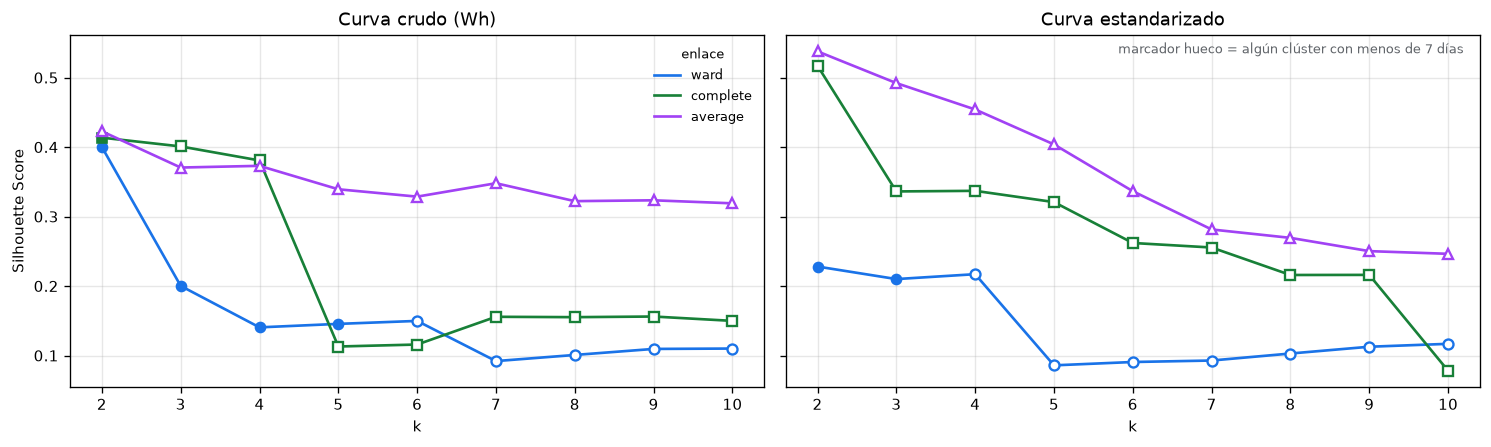

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8), sharey=True)
estilo = {"ward": (COL[0], "o"), "complete": (COL[2], "s"), "average": (COL["morado"], "^")}
for a, v in zip(ax, VERSIONES):
    t = BAR[BAR.version == v]
    for m in ENLACES:
        c, mk = estilo[m]
        s = t[t.enlace == m].set_index("k")
        a.plot(s.index, s.silueta, "-", color=c, lw=1.6, label=m)
        ok = s.menor >= MIN
        a.plot(s.index[ok], s.silueta[ok], mk, color=c, ms=6)
        a.plot(s.index[~ok], s.silueta[~ok], mk, color="white", mec=c, mew=1.4, ms=6)
    a.set(title=f"Curva {v}", xlabel="k", xticks=range(2, 11))
ax[0].set_ylabel("Silhouette Score")
ax[0].legend(frameon=False, fontsize=8, title="enlace", title_fontsize=8)
ax[1].text(10.2, ax[1].get_ylim()[1] - .01, f"marcador hueco = algún clúster con menos de {MIN} días",
           ha="right", va="top", fontsize=7.5, color=COL["gris"])
plt.tight_layout(); plt.savefig(FIG / "J2_silueta.png"); plt.show()

### La trampa: la mejor silueta de toda la tabla es la peor partición

| Enlace | k por silueta sola | Reparto | k con la regla del tamaño mínimo | Reparto |
|---|---|---|---|---|
| Ward | 2 (0,400) | 114 / 22 | **2** | 114 / 22 |
| Complete | 2 (0,414) | 114 / 22 | **2** | 114 / 22 |
| Average | 2 (**0,423**) | **135 / 1** | **ninguno** | — |

- **Ward** tiene un máximo nítido en k = 2 y cae a la mitad con k = 3 (0,200).
- **Complete** mantiene la silueta alta hasta k = 4 (0,401 y 0,381). Pero desde k = 3 lo hace
  separando un clúster de **2 días** (114 / 20 / 2), así que ese k no es válido.
- **Average obtiene la silueta más alta del barrido, 0,423, aislando un solo día** contra los otros
  135. Y no se corrige al subir k: en todo el rango de 2 a 10 deja al menos un clúster de un día.
  Con la regla del tamaño mínimo, *average* no produce **ninguna** partición utilizable.

La silueta no está mal calculada: mide lo que dice medir. Todos los días están lejos de ese día
extremo, así que la separación «135 contra 1» es muy nítida. **El índice de Dunn cae en la misma
trampa** (0,475 para *average* con k = 2, el máximo de la tabla). Las dos métricas responden «¿qué
tan separados están los grupos?», y Shiro pregunta otra cosa: **¿sirve esta partición como variable
de estado?** Elegida solo por la métrica, la variable «tipo de día» tendría un valor que ocurrió una
vez en 136 días.

**Con la regla, los dos enlaces válidos eligen k = 2 y el mismo tamaño de grupos (114 / 22)**, que
es también el k del C2-T2.

### 3.2 ¿Qué cambia si se estandariza?

In [9]:
km_c = KMeans(n_clusters=2, n_init=10, random_state=RS).fit_predict(X)
km_s = KMeans(n_clusters=2, n_init=10, random_state=RS).fit_predict(XS)
print(f"K-Means k=2 · crudo vs estandarizado: ARI = {adjusted_rand_score(km_c, km_s):.3f}")
for m in ENLACES:
    lc = fcluster(Z["crudo (Wh)"][m], 2, "maxclust"); ls = fcluster(Z["estandarizado"][m], 2, "maxclust")
    print(f"{m:9s} k=2 · crudo vs estandarizado: ARI = {adjusted_rand_score(lc, ls):.3f} · "
          f"tamaños crudo {sorted(np.bincount(lc)[1:].tolist(), reverse=True)} · "
          f"estandarizado {sorted(np.bincount(ls)[1:].tolist(), reverse=True)}")
print("\nMejor k por silueta con la versión estandarizada:")
print(elegir(BAR[BAR.version == "estandarizado"]).to_string())

print("\nDías que complete y average aíslan con la versión estandarizada (k = 2), y sus horas más atípicas:")
for m in ("complete", "average"):
    ls = fcluster(Z["estandarizado"][m], 2, "maxclust")
    for i in np.where(ls == np.argmin(np.bincount(ls)[1:]) + 1)[0]:
        top = np.argsort(-np.abs(XS[i]))[:2]
        print(f"  {m:9s} {NIVEL.index[i].date()} ({info.dia_semana.iloc[i]}): " +
              " · ".join(f"{X[i, h]:.0f} Wh a las {h} h (z = {XS[i, h]:.1f})" for h in top))

K-Means k=2 · crudo vs estandarizado: ARI = 1.000
ward      k=2 · crudo vs estandarizado: ARI = 0.655 · tamaños crudo [114, 22] · estandarizado [105, 31]
complete  k=2 · crudo vs estandarizado: ARI = -0.022 · tamaños crudo [114, 22] · estandarizado [134, 2]
average   k=2 · crudo vs estandarizado: ARI = -0.007 · tamaños crudo [135, 1] · estandarizado [135, 1]

Mejor k por silueta con la versión estandarizada:
         k solo silueta   silueta    tamaños k con regla silueta con regla tamaños con regla
ward                  2  0.228223  [105, 31]           2          0.228223         [105, 31]
complete              2  0.517212   [134, 2]        None               NaN                 —
average               2  0.537935   [135, 1]        None               NaN                 —

Días que complete y average aíslan con la versión estandarizada (k = 2), y sus horas más atípicas:
  complete  2016-01-12 (mar): 168 Wh a las 1 h (z = 9.4) · 142 Wh a las 0 h (z = 5.4)
  complete  2016-01-26 (mar): 

**En K-Means estandarizar no cambiaba nada (ARI 1,000). En el jerárquico lo cambia casi todo:**

- **Ward** pasa de 114 / 22 a 105 / 31, con un acuerdo de apenas 0,655 con su propia versión en Wh.
- **Complete** se vuelve degenerado: 134 / 2, sin relación con la versión en Wh (ARI −0,022). Su
  silueta *sube* a 0,517, otra vez premiando el aislamiento.
- **Average** sigue aislando un solo día.

La razón está en la varianza por hora: 50 a las 4 de la mañana frente a 12.477 a las 11. Estandarizar
multiplica por unas 16 la importancia de cada Wh de madrugada respecto de uno del mediodía. K-Means
lo resiste porque sus centroides promedian muchos días y la diferencia entre tipos, que está en el
bloque diurno, sigue dominando. *Complete* y *average* no promedian: deciden por distancias entre
días concretos, y una sola noche rara, amplificada, basta para dejar a un día solo. Es exactamente lo
que ocurre: con la versión estandarizada quedan aislados el **12-ene** (168 Wh a la 1 de la mañana,
9,4 desviaciones típicas por encima de lo normal a esa hora) y el **26-ene** (197 Wh a medianoche y
277 Wh a las 23 h). Dos días que, en Wh, no llaman la atención.

**Decisión:** la versión en Wh queda como principal, ahora con dos argumentos: las columnas
comparten unidad, y el escalado vuelve inestables a los enlaces que no promedian. La versión
estandarizada queda documentada como contraste.

### 3.3 El k elegido, la línea de corte y `fcluster()`

Para cada enlace se toma el k de mejor silueta **que respete el tamaño mínimo**. Cuando un enlace no
tiene ninguno, se muestra su óptimo por silueta para exhibir la trampa. La línea de corte se traza a
medio camino entre la fusión que deja k grupos y la siguiente. Se verifica que cortar por altura
(`criterion="distance"`) y cortar por número (`criterion="maxclust"`) den exactamente las mismas
etiquetas.

In [10]:
def ordenar(labels, X):
    # Renumera por consumo total del centroide: 0 = el de menor consumo
    u = np.unique(labels)
    tot = np.array([X[labels == c].sum(axis=1).mean() for c in u])
    mapa = {u[old]: new for new, old in enumerate(np.argsort(tot))}
    return np.vectorize(mapa.get)(labels)

KM2 = ordenar(km_c, X)                          # referencia del C2-T2: 0 = normal, 1 = carga alta
nombres = {0: "Día normal", 1: "Día de carga alta"}
print("K-Means k=2 (C2-T2):", {nombres[c]: int((KM2 == c).sum()) for c in (0, 1)})

K_ELEGIDO = {m: (ELEC.loc[m, "k con regla"] or ELEC.loc[m, "k solo silueta"]) for m in ENLACES}
ALTURA, ETQ = {}, {}
for m in ENLACES:
    k = int(K_ELEGIDO[m]); Zm = Z["crudo (Wh)"][m]
    ALTURA[m] = (Zm[-k, 2] + Zm[-k + 1, 2]) / 2        # a medio camino entre la fusión k-ésima y la (k−1)-ésima
    por_altura = fcluster(Zm, ALTURA[m], criterion="distance")
    por_k = fcluster(Zm, k, criterion="maxclust")
    assert adjusted_rand_score(por_altura, por_k) == 1.0
    ETQ[m] = por_altura
    altura = f"{ALTURA[m]:,.1f}".replace(",", "X").replace(".", ",").replace("X", ".")
    print(f"{m:9s} k = {k} · corte a la altura {altura} · tamaños {sorted(np.bincount(por_altura)[1:].tolist(), reverse=True)}"
          f" · fcluster por altura = fcluster por k ✔ · tres últimas fusiones {np.round(Zm[-3:, 2]).astype(int).tolist()}"
          f" (salto final ×{Zm[-1, 2] / Zm[-2, 2]:.2f})")

K-Means k=2 (C2-T2): {'Día normal': 108, 'Día de carga alta': 28}
ward      k = 2 · corte a la altura 2.228,1 · tamaños [114, 22] · fcluster por altura = fcluster por k ✔ · tres últimas fusiones [1299, 1605, 2851] (salto final ×1.78)
complete  k = 2 · corte a la altura 1.078,9 · tamaños [114, 22] · fcluster por altura = fcluster por k ✔ · tres últimas fusiones [907, 967, 1191] (salto final ×1.23)
average   k = 2 · corte a la altura 766,3 · tamaños [135, 1] · fcluster por altura = fcluster por k ✔ · tres últimas fusiones [706, 743, 790] (salto final ×1.06)


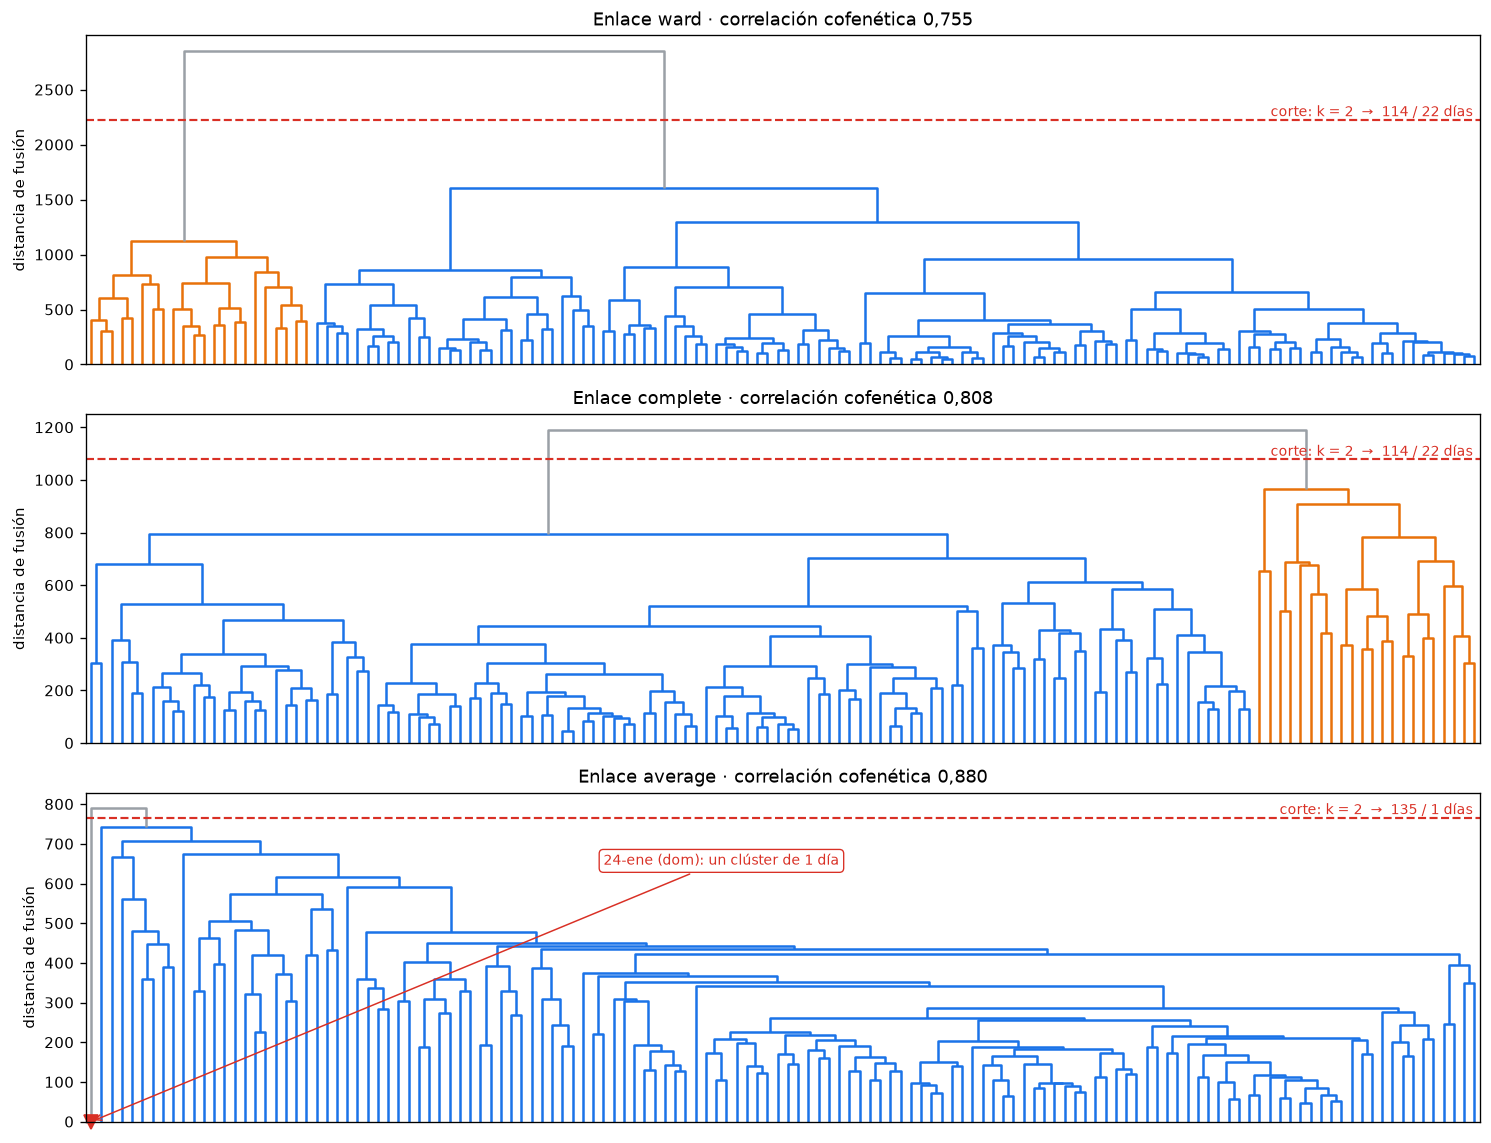

In [11]:
def paleta(labels, ref=KM2):
    # Cada clúster toma el color del tipo de K-Means que domina en él; los de menos de MIN días, rojo
    col, usados = {}, set()
    extra = iter([COL[2], COL["morado"], "#8d6e63", "#00897b", "#c2185b"])
    for c in sorted(np.unique(labels), key=lambda c: -(labels == c).sum()):
        if (labels == c).sum() < MIN:
            col[c] = COL["rojo"]; continue
        tipo = int(round(ref[labels == c].mean()))
        if tipo not in usados:
            col[c] = COL[tipo]; usados.add(tipo)
        else:
            col[c] = next(extra)
    return col

def colorear_ramas(Zm, labels, col):
    n = len(labels)
    miembros = {i: [i] for i in range(n)}
    for i, fila in enumerate(Zm):
        miembros[n + i] = miembros[int(fila[0])] + miembros[int(fila[1])]
    def f(nodo):
        labs = set(labels[miembros[nodo]])
        return col[labs.pop()] if len(labs) == 1 else "#9aa0a6"
    return f

fig, ax = plt.subplots(3, 1, figsize=(12.5, 9.6))
for a, m in zip(ax, ENLACES):
    Zm = Z["crudo (Wh)"][m]; col = paleta(ETQ[m])
    dd = dendrogram(Zm, no_labels=True, link_color_func=colorear_ramas(Zm, ETQ[m], col), ax=a)
    for c in np.unique(ETQ[m]):                       # señalar los clústers de 1–2 días
        if (ETQ[m] == c).sum() <= 2:
            for i in np.where(ETQ[m] == c)[0]:
                x = 5 + 10 * dd["leaves"].index(i)
                a.plot(x, 0, "v", color=COL["rojo"], ms=8, clip_on=False)
                a.annotate(f"{fecha(NIVEL.index[i])} ({info.dia_semana.iloc[i]}): un clúster de 1 día", (x, 0),
                           (x + 500, Zm[-1, 2] * .82), fontsize=8.5, color=COL["rojo"],
                           bbox=dict(boxstyle="round,pad=.3", fc="white", ec=COL["rojo"], lw=.8),
                           arrowprops=dict(arrowstyle="->", color=COL["rojo"], lw=.9))
    a.axhline(ALTURA[m], color=COL["rojo"], ls="--", lw=1.3)
    tam = sorted(np.bincount(ETQ[m])[1:].tolist(), reverse=True)
    a.text(a.get_xlim()[1] * .995, ALTURA[m], f" corte: k = {K_ELEGIDO[m]}  →  {' / '.join(map(str, tam))} días",
           color=COL["rojo"], ha="right", va="bottom", fontsize=8.5)
    a.set(ylabel=f"distancia de fusión", title=f"Enlace {m} · correlación cofenética {cof.loc[m, 'crudo (Wh)']:.3f}".replace(".", ","))
    a.grid(False)
plt.tight_layout(); plt.savefig(FIG / "J1_dendrogramas.png"); plt.show()

**Cómo leer los tres árboles.** La altura de cada unión es la distancia a la que se fusionaron dos
grupos. Un buen corte está donde hay un salto grande entre una fusión y la siguiente.

- **Ward:** la última fusión (2.851) está 1,78 veces por encima de la anterior (1.605). Es el salto
  más claro de los tres: dos ramas que el árbol solo une a la fuerza. El corte en 2.228 deja los
  114 días normales (azul) y los 22 de carga alta (naranja).
- **Complete:** el mismo reparto de tamaños, con un salto final menor (×1,23). La rama naranja,
  a la derecha, termina de unirse a 967, casi a la altura de la fusión final (1.191): con
  *complete*, los días de carga alta están casi tan lejos entre sí como de los normales. Es la
  periferia dispersa que se verá otra vez en §6.1.
- **Average:** el árbol es una **cadena**. Los días se van sumando uno a uno a un gran grupo, sin
  ramas separadas, y la última fusión (790) apenas supera a la anterior (×1,06). Es la última
  porque solo añade el 24 de enero, el día más distinto de todos. No hay salto que cortar: el corte
  en k = 2 separa un día del resto porque es lo único que *average* puede separar.

**La paradoja de la correlación cofenética:** *average* es el árbol que mejor conserva las
distancias entre días (0,880, frente a 0,808 y 0,755), y es el que produce la partición inútil.
Conservar bien las distancias no es lo mismo que encontrar grupos. Cuando los datos son una nube
central con una periferia dispersa, el árbol fiel a las distancias es una cadena.

---
## 4. Visualización en 2D: PCA y t-SNE

Se usan **las mismas proyecciones del C2-T2**: PCA de 2 componentes y t-SNE con perplexity 15,
learning rate 200 e inicialización PCA, con semilla 42. Así cada punto está exactamente donde estaba
en el taller de K-Means y la comparación es visual, punto a punto. Los clústers se calculan siempre
en el espacio original de 24 horas; la proyección solo sirve para mirar. Los **rombos con borde
negro** son los días que cambian de tipo respecto de K-Means.

PCA: PC1 37.2 % + PC2 12.9 % = 50.1 % de la varianza


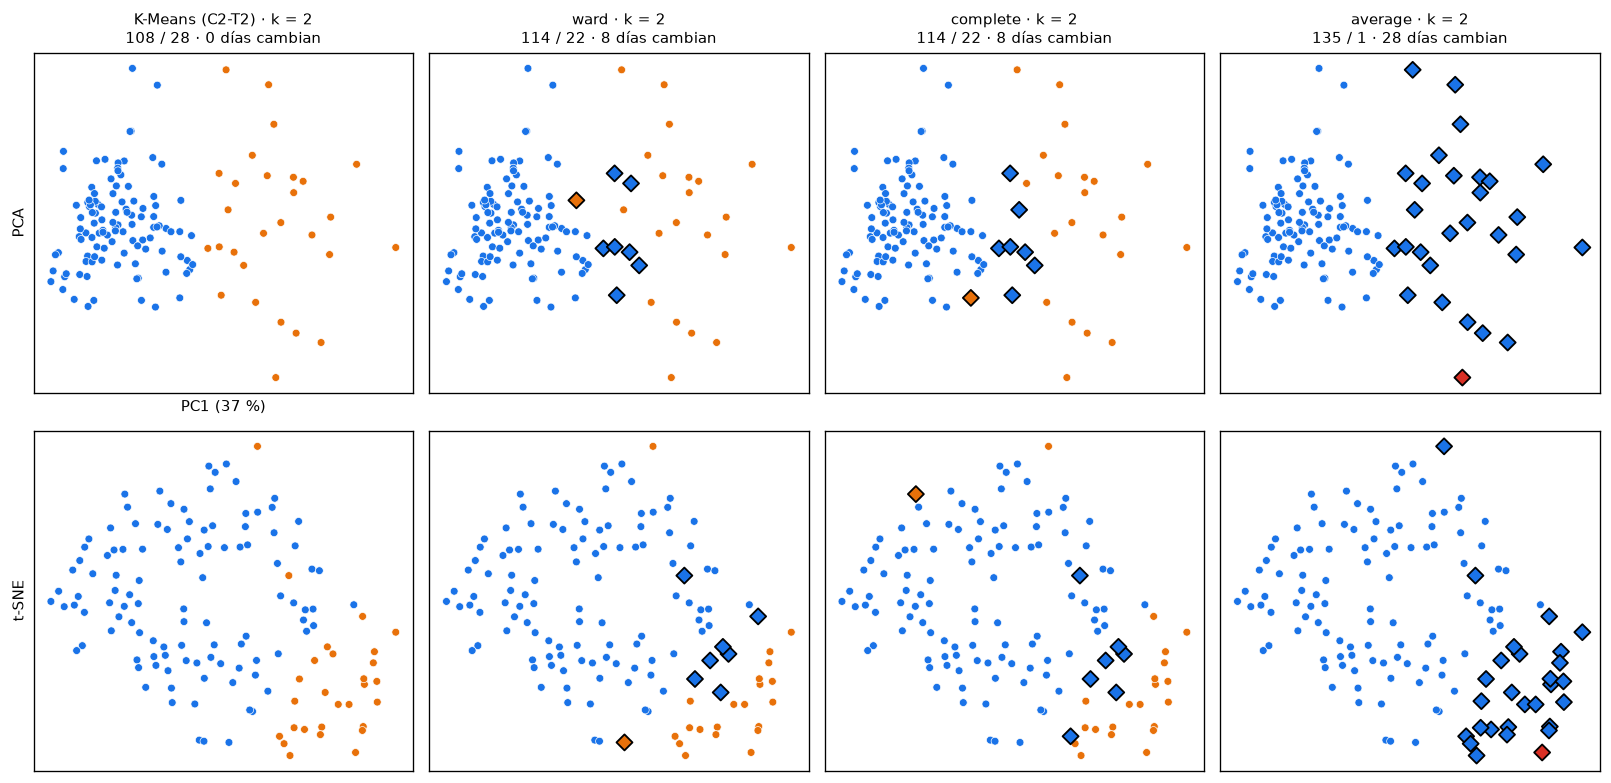

In [12]:
pca = PCA(n_components=2).fit(X)
P = pca.transform(X); ev = pca.explained_variance_ratio_
TS = TSNE(n_components=2, perplexity=15, learning_rate=200, init="pca", random_state=RS).fit_transform(X)
print(f"PCA: PC1 {ev[0]*100:.1f} % + PC2 {ev[1]*100:.1f} % = {ev.sum()*100:.1f} % de la varianza")

PANELES = [("K-Means (C2-T2)", KM2 + 1)] + [(m, ETQ[m]) for m in ENLACES]
difiere = {m: None for m in ENLACES}

def tipo_de(labels):
    # Traduce etiquetas de un enlace a 0/1 por el tipo de K-Means dominante (los clústers chicos → -1)
    out = np.full(len(labels), -1)
    for c in np.unique(labels):
        if (labels == c).sum() >= MIN:
            out[labels == c] = int(round(KM2[labels == c].mean()))
    return out

fig, ax = plt.subplots(2, 4, figsize=(13.5, 6.6))
for j, (nom, lab) in enumerate(PANELES):
    col = paleta(lab) if j else {1: COL[0], 2: COL[1]}
    cambia = (tipo_de(lab) != KM2) if j else np.zeros(len(X), bool)
    for fila, (C2, titulo) in enumerate([(P, "PCA"), (TS, "t-SNE (perplexity 15)")]):
        a = ax[fila, j]
        a.scatter(C2[~cambia, 0], C2[~cambia, 1], c=[col[l] for l in lab[~cambia]], s=22,
                  edgecolors="white", linewidths=.4)
        a.scatter(C2[cambia, 0], C2[cambia, 1], c=[col[l] for l in lab[cambia]], s=46,
                  edgecolors="black", linewidths=1.1, marker="D")
        if fila == 0:
            tam = sorted(np.bincount(lab)[1:].tolist(), reverse=True)
            a.set_title(f"{nom} · k = {len(tam)}\n{' / '.join(map(str, tam))} · {cambia.sum()} días cambian", fontsize=9)
        a.set(xticks=[], yticks=[])
    ax[0, j].set_xlabel(f"PC1 ({ev[0]*100:.0f} %)") if j == 0 else None
ax[0, 0].set_ylabel("PCA"); ax[1, 0].set_ylabel("t-SNE")
plt.tight_layout(); plt.savefig(FIG / "J4_proyecciones.png"); plt.show()

**¿Cómo se separan los clústeres?** PCA retiene el 50,1 % de la varianza (37,2 % + 12,9 %) y
vuelve a mostrar lo que vio el C2-T2: una nube densa de días normales a la izquierda y los días de
carga alta dispersos hacia la derecha a lo largo de PC1, que es la dirección de «cuánto se consume
de día». **Ward y complete dibujan la misma frontera que K-Means**, y los 8 días que cambian de
grupo (rombos) están todos en la zona de contacto entre las dos nubes, ninguno en el interior de
ninguna.

*Average* es la excepción visible: pinta de azul a los 28 días de carga alta y deja en rojo un
solo punto, en el borde inferior de la nube.

En t-SNE la lectura es la misma. Los días de carga alta se concentran en el borde inferior
derecho, los rombos quedan en la costura y no aparece ninguna estructura que PCA no mostrara. Como
en el C2-T2, t-SNE no revela nada oculto porque la diferencia entre tipos es de intensidad, una
dirección lineal que PCA ya captura.

---
## 5. Análisis: qué tienen en común los días de cada grupo

### 5.1 Caracterización con variables que no entraron al clustering

In [13]:
WARD = ordenar(ETQ["ward"], X) if len(np.unique(ETQ["ward"])) == 2 else None
COMP = ordenar(ETQ["complete"], X) if len(np.unique(ETQ["complete"])) == 2 else None
print(f"Ward frente a complete (k = 2): mismos tamaños {sorted(np.bincount(WARD).tolist(), reverse=True)} y "
      f"{sorted(np.bincount(COMP).tolist(), reverse=True)} · ARI {adjusted_rand_score(WARD, COMP):.3f} · "
      f"coinciden en {(WARD == COMP).sum()} de {len(X)} días")
for i in np.where(WARD != COMP)[0]:
    print(f"   {NIVEL.index[i].date()} ({info.dia_semana.iloc[i]}, {info.kwh_dia.iloc[i]:.1f} kWh): "
          f"Ward → {nombres[WARD[i]]} · complete → {nombres[COMP[i]]} · K-Means → {nombres[KM2[i]]}")

vars_ = ["kwh_dia", "Wh_8a18", "pico_Wh", "hora_pico", "lights_Wh", "RH_3_lavanderia", "RH_1_cocina", "T_out", "fin_de_semana"]
def resumen(lab, etiqueta):
    t = info.assign(tipo=[nombres[c] for c in lab]).groupby("tipo")[vars_].mean()
    t.insert(0, "días", pd.Series(lab).map(nombres).value_counts())
    t["fin_de_semana"] *= 100
    t.index = [f"{etiqueta} · {i}" for i in t.index]
    return t
TAB = pd.concat([resumen(KM2, "K-Means"), resumen(WARD, "Ward")])
TAB = TAB.rename(columns={"kwh_dia": "kWh/día", "Wh_8a18": "Wh medio 8–18 h", "pico_Wh": "pico (Wh)",
                          "hora_pico": "hora pico media", "lights_Wh": "lights (Wh/día)",
                          "RH_3_lavanderia": "RH_3 lavandería (%)", "RH_1_cocina": "RH_1 cocina (%)",
                          "fin_de_semana": "% fin de semana"})
print(TAB.round(1).T.to_string())

Ward frente a complete (k = 2): mismos tamaños [114, 22] y [114, 22] · ARI 0.855 · coinciden en 132 de 136 días
   2016-01-17 (dom, 20.6 kWh): Ward → Día normal · complete → Día de carga alta · K-Means → Día de carga alta
   2016-02-03 (mié, 19.1 kWh): Ward → Día de carga alta · complete → Día normal · K-Means → Día de carga alta
   2016-04-09 (sáb, 15.2 kWh): Ward → Día de carga alta · complete → Día normal · K-Means → Día normal
   2016-04-15 (vie, 18.9 kWh): Ward → Día normal · complete → Día de carga alta · K-Means → Día normal
                     K-Means · Día de carga alta  K-Means · Día normal  Ward · Día de carga alta  Ward · Día normal
días                                        28.0                 108.0                      22.0              114.0
kWh/día                                     20.9                  12.2                      21.6               12.6
Wh medio 8–18 h                            231.1                  93.3                     241.8               98.

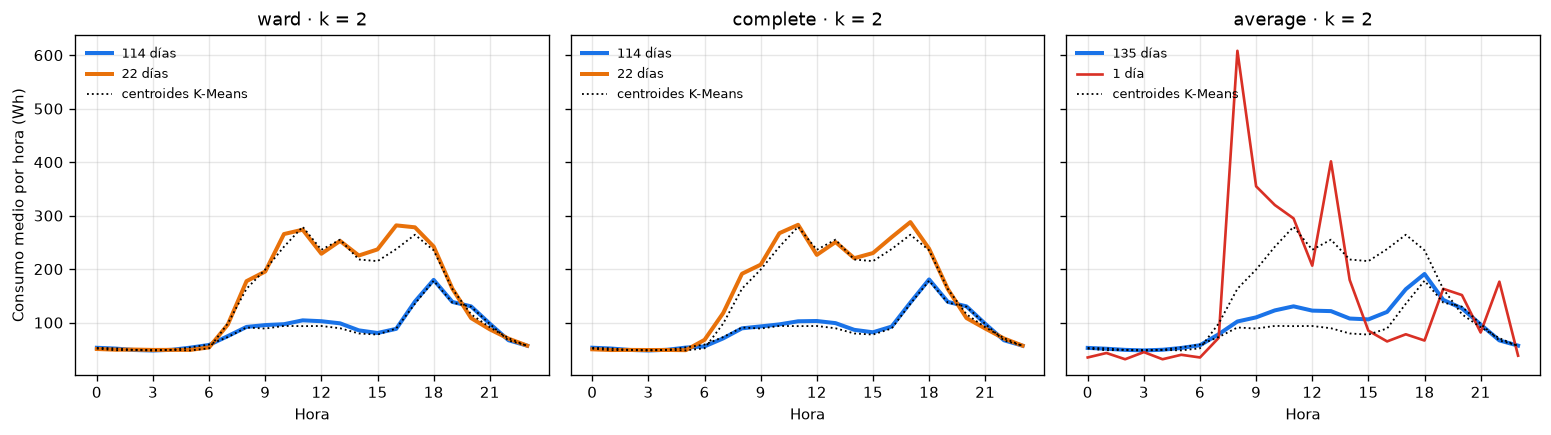

In [14]:
horas = np.arange(24)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.7), sharey=True)
cen_km = np.vstack([X[KM2 == c].mean(axis=0) for c in (0, 1)])
for a, m in zip(ax, ENLACES):
    lab = ETQ[m]; col = paleta(lab)
    for c in sorted(np.unique(lab), key=lambda c: -(lab == c).sum()):
        n = (lab == c).sum()
        a.plot(horas, X[lab == c].mean(axis=0), color=col[c], lw=2.4 if n >= MIN else 1.6,
               label=f"{n} día{'s' if n > 1 else ''}")
    for c in (0, 1):
        a.plot(horas, cen_km[c], color="black", ls=":", lw=1.1, label="centroides K-Means" if c == 0 else None)
    a.set(title=f"{m} · k = {K_ELEGIDO[m]}", xlabel="Hora", xticks=range(0, 24, 3))
    a.legend(frameon=False, fontsize=7.5, loc="upper left")
ax[0].set_ylabel("Consumo medio por hora (Wh)")
plt.tight_layout(); plt.savefig(FIG / "J5_perfiles.png"); plt.show()

**Las curvas medias de Ward y complete se superponen a los centroides de K-Means** (línea punteada).
Solo cambia el nivel: el día de carga alta de Ward consume 21,6 kWh, frente a 20,9 en K-Means,
porque Ward le quita 7 días de frontera de 16–21 kWh.

**¿Qué tienen en común los días de cada grupo?** La tabla confirma, con la partición de Ward, la
caracterización del C2-T2:

- **Día de carga alta (22 días):** un bloque diurno fuerte, con 241,8 Wh por hora de media entre
  las 8 y las 18 h frente a 98,5 del día normal (2,5 veces), y el pico hacia las 13 h. Tiene más
  iluminación (645 frente a 522 Wh/día, +24 %) y más humedad en la cocina (41,7 % frente a 39,9 %)
  y en la lavandería (40,3 % frente a 39,0 %). Son rastros de actividad dentro de la casa:
  cocinar, lavar, secar.
- **Día normal (114 días):** su curva media es plana durante el día, con un único pico hacia las
  18 h: la vuelta a casa.
- **Lo que no tienen en común:** el calendario. Hay un 27,3 % de días de fin de semana en un grupo
  y un 28,1 % en el otro, prácticamente lo mismo que en el C2-T2. La temperatura exterior difiere en
  1 °C (8,2 frente a 7,2), una diferencia menor que la variación dentro de cada grupo.

El panel de *average* muestra por qué su partición no sirve: su «clúster» de 135 días es,
sencillamente, el día promedio de la casa, y el otro es un solo día con un pico de 608 Wh a las 8 de
la mañana.

### 5.2 Ejemplos representativos por clúster

El ejemplo representativo de un clúster es su **medoide**: el día real con menor distancia media al
resto de su grupo. Se prefiere al centroide porque el centroide es un promedio que no ocurrió nunca,
y el medoide es un día que la casa sí vivió. La tabla incluye los dos días más típicos después del
medoide y, al final, los días que *complete* o *average* dejan aislados en algún corte con k de 2 a 4.

In [15]:
D = pairwise_distances(X)
ver = ["dia_semana", "kwh_dia", "hora_pico", "pico_Wh", "lights_Wh", "T_out"]
filas = []
for c in (0, 1):
    idx = np.where(WARD == c)[0]
    tipicidad = D[np.ix_(idx, idx)].sum(axis=1) / (len(idx) - 1)      # distancia media al resto de su clúster
    for rango, i in enumerate(idx[np.argsort(tipicidad)][:3]):
        filas.append({"clúster (Ward)": nombres[c], "papel": "medoide" if rango == 0 else f"{rango + 1}.º más típico",
                      "fecha": str(NIVEL.index[i].date()), **info.iloc[i][ver].to_dict(),
                      "dist. media a su grupo": tipicidad[np.argsort(tipicidad)][rango]})
MEDOIDE = {c: np.where(WARD == c)[0][np.argmin(D[np.ix_(np.where(WARD == c)[0], np.where(WARD == c)[0])].sum(axis=1))] for c in (0, 1)}

# Días que average o complete dejan aislados (clústers de 1 o 2 días) en algún corte con k = 2…4
raros = set()
for m in ("complete", "average"):
    for k in (2, 3, 4):
        lab = fcluster(Z["crudo (Wh)"][m], k, "maxclust")
        for c in np.unique(lab):
            if (lab == c).sum() <= 2:
                raros.update(np.where(lab == c)[0].tolist())
for i in sorted(raros):
    filas.append({"clúster (Ward)": nombres[WARD[i]], "papel": "aislado por average/complete",
                  "fecha": str(NIVEL.index[i].date()), **info.iloc[i][ver].to_dict(),
                  "dist. media a su grupo": D[i, WARD == WARD[i]].sum() / ((WARD == WARD[i]).sum() - 1)})
REP = pd.DataFrame(filas)
print(REP.round(1).to_string(index=False))

   clúster (Ward)                        papel      fecha dia_semana  kwh_dia  hora_pico  pico_Wh  lights_Wh  T_out  dist. media a su grupo
       Día normal                      medoide 2016-04-27        mié     10.8         18    163.3        750    4.8                   264.9
       Día normal               2.º más típico 2016-03-27        dom     10.5         18    156.7         80    9.0                   272.0
       Día normal               3.º más típico 2016-03-30        mié     12.6         20    196.7        620    9.1                   273.6
Día de carga alta                      medoide 2016-02-03        mié     19.1         16    320.0       1180    4.9                   489.3
Día de carga alta               2.º más típico 2016-04-16        sáb     19.3         16    441.7         50    9.1                   510.0
Día de carga alta               3.º más típico 2016-02-29        lun     22.6         12    368.3        760    2.2                   529.3
Día de carga alta ai

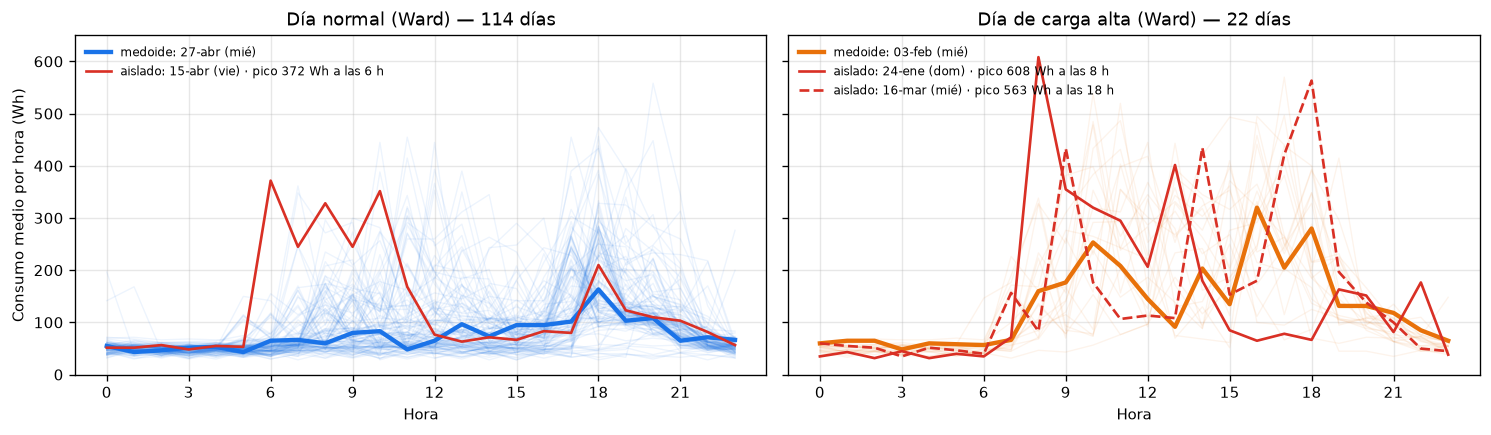

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.7), sharey=True)
for a, c in zip(ax, (0, 1)):
    for i in np.where(WARD == c)[0]:
        a.plot(horas, X[i], color=COL[c], alpha=.08, lw=.8)
    i = MEDOIDE[c]
    a.plot(horas, X[i], color=COL[c], lw=2.6, label=f"medoide: {fecha(NIVEL.index[i])} ({info.dia_semana.iloc[i]})")
    for j, i in enumerate(sorted(r for r in raros if WARD[r] == c)):
        a.plot(horas, X[i], color=COL["rojo"], lw=1.6, ls=["-", "--", ":", "-."][j % 4],
               label=f"aislado: {fecha(NIVEL.index[i])} ({info.dia_semana.iloc[i]}) · pico {info.pico_Wh.iloc[i]:.0f} Wh a las {info.hora_pico.iloc[i]} h")
    a.set(title=f"{nombres[c]} (Ward) — {(WARD == c).sum()} días", xlabel="Hora", xticks=range(0, 24, 3), ylim=(0, 650))
    a.legend(frameon=False, fontsize=7.3, loc="upper left")
ax[0].set_ylabel("Consumo medio por hora (Wh)")
plt.tight_layout(); plt.savefig(FIG / "J6_representativos.png"); plt.show()

**Los medoides son días de manual.**

- El **día normal más típico es el miércoles 27 de abril**: 10,8 kWh, con el pico a las 18 h
  (163 Wh). Sus dos siguientes son un domingo (27-mar) y otro miércoles (30-mar), los dos con el
  pico entre las 18 y las 20 h. Que un domingo sea de los días normales más típicos es otra forma de
  ver que el calendario no define el tipo.
- El **día de carga alta más típico es el miércoles 3 de febrero**: 19,1 kWh, con el pico a las
  16 h. Lo siguen un sábado (16-abr) y un lunes (29-feb).

**Los días aislados por *average* y *complete* son raros por *cuándo* consumen, no por *cuánto*.**
Ninguno es el día de mayor consumo: el 4 de abril (27,2 kWh) y el 25 de marzo (26,0) consumen más y
no quedan aislados.

| Día | Qué lo hace raro |
|---|---|
| **Dom 24-ene** · 21,6 kWh | Un pico de **608 Wh a las 8 de la mañana**, la hora más alta de todo el periodo, a una hora en que ningún otro día consume así |
| **Mié 16-mar** · 22,8 kWh | Tres picos separados (9, 14 y 18 h), el último de 563 Wh |
| **Vie 15-abr** · 18,9 kWh | Carga fuerte **desde las 6 de la mañana** (372 Wh) y una tarde normal. Ward lo llama «normal» y complete, «carga alta»: no encaja en ninguno |

Para Shiro no son errores de medición: son días reales, y precisamente los días en que la
estimación del tipo de día fallaría. El gemelo no debería aprenderlos como rutina, pero tampoco
borrarlos. Encontrarlos con un método diseñado para eso es el objetivo del taller de DBSCAN.

### 5.3 Lo que K-Means no da: la jerarquía

El árbol de Ward contiene todas las particiones a la vez. ¿Qué se separa en los niveles siguientes?

In [17]:
Zw = Z["crudo (Wh)"]["ward"]
for k in (2, 3, 4):
    lab = fcluster(Zw, k, "maxclust")
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RS).fit_predict(X)
    cruce = pd.crosstab(pd.Series(lab, name=f"Ward k={k}"), pd.Series(KM2, name="K-Means k=2").map(nombres))
    cruce["kWh/día"] = info.groupby(lab)["kwh_dia"].mean().values
    cruce["% fin de semana"] = info.groupby(lab)["fin_de_semana"].mean().values * 100
    print(f"— Ward k = {k} · ARI con K-Means k = {k}: {adjusted_rand_score(lab, km_k):.3f}")
    print(cruce.round(1).to_string(), "\n")

— Ward k = 2 · ARI con K-Means k = 2: 0.736
K-Means k=2  Día de carga alta  Día normal  kWh/día  % fin de semana
Ward k=2                                                            
1                           21           1     21.6             27.3
2                            7         107     12.6             28.1 

— Ward k = 3 · ARI con K-Means k = 3: 0.796
K-Means k=2  Día de carga alta  Día normal  kWh/día  % fin de semana
Ward k=3                                                            
1                           21           1     21.6             27.3
2                            7          21     15.4             46.4
3                            0          86     11.6             22.1 

— Ward k = 4 · ARI con K-Means k = 4: 0.543
K-Means k=2  Día de carga alta  Día normal  kWh/día  % fin de semana
Ward k=4                                                            
1                           21           1     21.6             27.3
2                            7      

**El árbol tiene tres niveles legibles, y el tercero ya lo había encontrado K-Means.**

- **k = 2:** carga alta (22) frente a normal (114).
- **k = 3:** los días normales se parten en 86 días bajos (11,6 kWh, 22,1 % de fin de semana) y un
  grupo **intermedio** de 28 (15,4 kWh, **46,4 % de fin de semana**), que contiene los 7 días de
  frontera. Es la «mañana activa» del C2-T2 (48 % de fin de semana): Ward y K-Means con k = 3
  coinciden con un ARI de 0,796, más alto que con k = 2.
- **k = 4:** el grupo bajo se parte en 61 + 25 (11,0 frente a 13,2 kWh), sin ninguna señal de
  calendario, y el acuerdo con K-Means cae a 0,543. Por debajo de este nivel las técnicas dejan de
  coincidir: ya no hay estructura, solo cortes arbitrarios de la nube.

Para Shiro esto separa dos usos. El **MDP** se queda con k = 2, decidido en el C2-T2 por silueta y
por observabilidad. La **capa de explicación** puede usar el tercer nivel para decir más que
«normal»: «un día normal con mañana activa, típico de fin de semana».

---
## 6. Comparación con K-Means

### 6.1 ¿Cambió la forma de los clústeres?

In [18]:
def forma(lab, nom):
    filas = []
    for c in np.unique(lab):
        idx = np.where(lab == c)[0]
        cen = X[idx].mean(axis=0)
        sub = D[np.ix_(idx, idx)]
        filas.append({"técnica": nom, "clúster": nombres.get(c, c), "días": len(idx),
                      "radio medio (Wh)": np.linalg.norm(X[idx] - cen, axis=1).mean(),
                      "distancia media interna": sub.sum() / max(len(idx) * (len(idx) - 1), 1),
                      "diámetro (Wh)": sub.max()})
    return filas
inercia = lambda lab: sum(((X[lab == c] - X[lab == c].mean(axis=0)) ** 2).sum() for c in np.unique(lab))
FORMA_T = pd.DataFrame(forma(KM2, "K-Means") + forma(WARD, "Ward"))
print(FORMA_T.round(1).to_string(index=False))
print(f"\nInercia intra-clúster (lo que ambos minimizan): K-Means {inercia(KM2):,.0f} · Ward {inercia(WARD):,.0f}"
      f" (+{(inercia(WARD) / inercia(KM2) - 1) * 100:.1f} %)".replace(",", "."))

técnica           clúster  días  radio medio (Wh)  distancia media interna  diámetro (Wh)
K-Means        Día normal   108             235.0                    339.6          813.4
K-Means Día de carga alta    28             405.7                    583.9          966.7
   Ward        Día normal   114             249.4                    360.2          866.6
   Ward Día de carga alta    22             411.3                    595.6          966.7

Inercia intra-clúster (lo que ambos minimizan): K-Means 11.755.083 · Ward 12.206.598 (+3.8 %)


**La forma casi no cambió.** Las dos técnicas ven lo mismo: un **núcleo compacto de días normales**
(radio medio de 235 Wh en K-Means) y una **periferia dispersa de días de carga alta**, 1,7 veces más
abierta (406 Wh). Ward mueve 7 días de frontera al lado normal, y eso ensancha un poco el grupo
normal (radio 249, diámetro 867 frente a 813). El diámetro del grupo de carga alta no cambia
(967 Wh): lo fijan los mismos dos días extremos.

**¿Por qué dos métodos que minimizan lo mismo no llegan a lo mismo?** K-Means y Ward minimizan la
inercia intra-clúster, pero K-Means llega a un valor **3,8 % más bajo** (11.755.083 frente a
12.206.598). K-Means puede reasignar cualquier día en cada iteración. Ward es **codicioso**: toma 134
decisiones de fusión, una tras otra, y **nunca deshace una**. Los días de frontera quedaron unidos
temprano a grupos del lado normal y ya no pudieron salir.

*Average* sí cambia la forma por completo (un punto frente al resto), pero no es una forma
utilizable.

### 6.2 ¿Se mantuvieron algunos agrupamientos?

In [19]:
for m in ENLACES:
    t = tipo_de(ETQ[m])
    print(f"{m:9s} · ARI con K-Means {adjusted_rand_score(KM2, ETQ[m]):.3f} · días con distinto tipo: {(t != KM2).sum()}")
print()
print(pd.crosstab(pd.Series(KM2, name="K-Means").map(nombres), pd.Series(WARD, name="Ward").map(nombres),
                  margins=True, margins_name="total").to_string())

# ¿Los días que cambian son de frontera? Margen relativo respecto de los dos centroides de K-Means
dn = np.linalg.norm(X - cen_km[0], axis=1); da = np.linalg.norm(X - cen_km[1], axis=1)
margen = (dn - da) / (dn + da)                      # < 0: más cerca de «normal»; > 0: más cerca de «carga alta»
CAMBIA = WARD != KM2
rango = pd.Series(np.abs(margen)).rank(pct=True).values * 100
print(f"\nDías que cambian: {CAMBIA.sum()} · |margen| medio {np.abs(margen[CAMBIA]).mean():.3f} "
      f"frente a {np.abs(margen[~CAMBIA]).mean():.3f} de los que no cambian")
print(f"Todos están entre el {rango[CAMBIA].max():.0f} % de días más cercanos a la frontera de K-Means")
print(info.loc[CAMBIA, ["dia_semana", "kwh_dia", "hora_pico", "pico_Wh"]].assign(
    **{"K-Means": [nombres[c] for c in KM2[CAMBIA]], "Ward": [nombres[c] for c in WARD[CAMBIA]],
       "margen": margen[CAMBIA]}).round(3).to_string())

ward      · ARI con K-Means 0.736 · días con distinto tipo: 8
complete  · ARI con K-Means 0.736 · días con distinto tipo: 8
average   · ARI con K-Means 0.041 · días con distinto tipo: 28

Ward               Día de carga alta  Día normal  total
K-Means                                                
Día de carga alta                 21           7     28
Día normal                         1         107    108
total                             22         114    136

Días que cambian: 8 · |margen| medio 0.110 frente a 0.358 de los que no cambian
Todos están entre el 20 % de días más cercanos a la frontera de K-Means
           dia_semana  kwh_dia  hora_pico  pico_Wh            K-Means               Ward  margen
dia                                                                                             
2016-01-17        dom    20.55         17  455.000  Día de carga alta         Día normal   0.096
2016-01-31        dom    18.64         12  393.333  Día de carga alta         Día normal

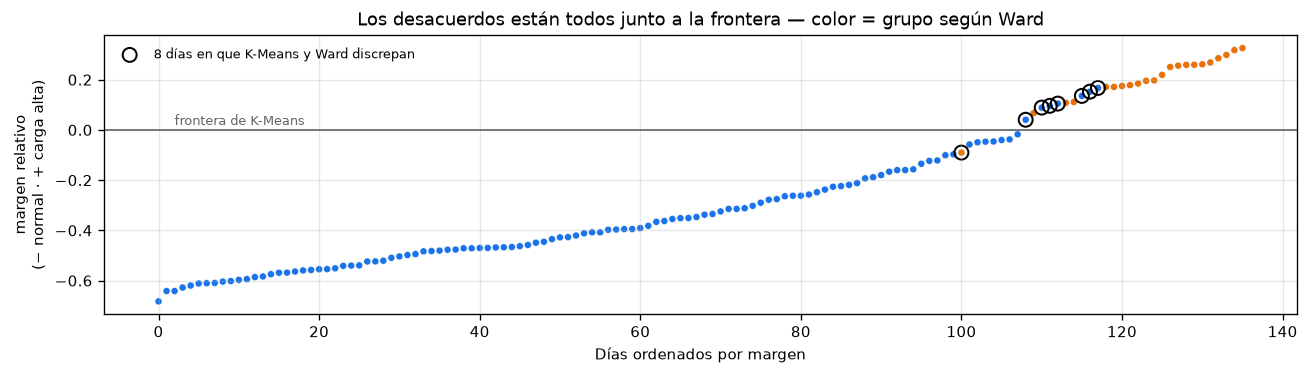

In [20]:
fig, ax = plt.subplots(figsize=(11, 3.2))
orden = np.argsort(margen)
ax.scatter(np.arange(len(X)), margen[orden], c=[COL[c] for c in WARD[orden]], s=18, edgecolors="white", linewidths=.3)
ax.scatter(np.where(CAMBIA[orden])[0], margen[orden][CAMBIA[orden]], s=70, facecolors="none", edgecolors="black", lw=1.2,
           label=f"{CAMBIA.sum()} días en que K-Means y Ward discrepan")
ax.axhline(0, color=COL["gris"], lw=1)
ax.text(2, .02, "frontera de K-Means", color=COL["gris"], fontsize=8)
ax.set(xlabel="Días ordenados por margen", ylabel="margen relativo\n(− normal · + carga alta)",
       title="Los desacuerdos están todos junto a la frontera — color = grupo según Ward")
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(FIG / "J7_frontera.png"); plt.show()

**Sí: 128 de los 136 días (94 %) conservan su grupo.** Los 21 días de carga alta y los 107 días
normales que comparten K-Means y Ward son el núcleo de cada tipo. *Complete* coincide con Ward en 132
de 136 días (ARI 0,855), y cada uno discrepa de K-Means en 8 días (ARI 0,736 los dos).

**Lo que cambia es solo la frontera, y se puede medir.** Para cada día se calcula su margen: qué tan
más cerca está de un centroide de K-Means que del otro. Los 8 días en que K-Means y Ward discrepan
tienen un margen medio de 0,110, frente a 0,358 del resto, y **todos están entre el 20 % de días más
cercanos a la frontera**. Son días de «carga alta moderada»: de 15 a 21 kWh, con picos de 317 a
455 Wh.

**Consecuencia para Shiro.** El tipo de día es robusto en su núcleo y difuso en su borde. Refuerza
la decisión del C2-T2: la variable entra al MDP como **estimación con confianza**, no como etiqueta.
El margen relativo es una medida natural de esa confianza. Un día con margen cercano a cero es
«incierto», y el agente no debería apostar una acción diferible a un tipo que ni siquiera dos
algoritmos se ponen de acuerdo en asignar.

### 6.3 Control temporal y estabilidad: ¿el árbol se sostiene cuando llegan días nuevos?

En producción, Shiro recibe un día nuevo cada 24 horas. Se ajusta cada técnica solo con los 110 días
hasta el 30 de abril y se mide tres cosas: si el reparto de esos 110 días es el mismo que con los 136
(ARI), cómo se asignan los 26 días de mayo (por el centroide más cercano, porque el jerárquico no
tiene `predict`) y si esa asignación coincide con la de ajustar sobre todo. Al final, el determinismo:
K-Means depende de su inicialización y el jerárquico no.

In [21]:
tr = info["entrenamiento"].values == 1
filas = []
for nom, ajustar in [("K-Means", lambda V: ordenar(KMeans(n_clusters=2, n_init=10, random_state=RS).fit_predict(V), V)),
                     ("Ward", lambda V: ordenar(fcluster(linkage(V, "ward"), 2, "maxclust"), V)),
                     ("complete", lambda V: ordenar(fcluster(linkage(V, "complete"), 2, "maxclust"), V))]:
    todo = ajustar(X); solo_tr = ajustar(X[tr])
    cen = np.vstack([X[tr][solo_tr == c].mean(axis=0) for c in (0, 1)])
    mayo = np.linalg.norm(X[~tr][:, None, :] - cen[None], axis=2).argmin(axis=1)   # centroide más cercano
    filas.append({"técnica": nom, "ARI (110 días) vs (136 días)": adjusted_rand_score(todo[tr], solo_tr),
                  "tamaños con 110 días": sorted(np.bincount(solo_tr).tolist(), reverse=True),
                  "% carga alta ene–abr": solo_tr.mean() * 100, "% carga alta mayo": mayo.mean() * 100,
                  "mayo igual que con 136 días": (mayo == todo[~tr]).mean() * 100})
print(pd.DataFrame(filas).set_index("técnica").round(3).to_string())

# ¿Qué cambia en el árbol de Ward al quitar mayo? Se cruza su corte k=2 (110 días) con el de k=3 (136 días)
w110 = ordenar(fcluster(linkage(X[tr], "ward"), 2, "maxclust"), X[tr])
w136_3 = ordenar(fcluster(Zw, 3, "maxclust"), X)[tr]
print("\nWard con 110 días (k=2) frente a Ward con 136 días (k=3), sobre los mismos 110 días:")
print(pd.crosstab(pd.Series(w110, name="Ward 110 días, k=2").map({0: "bajo", 1: "alto"}),
                  pd.Series(w136_3, name="Ward 136 días, k=3").map({0: "normal", 1: "intermedio", 2: "carga alta"})).to_string())
Zw110 = linkage(X[tr], "ward")
print(f"Alturas de las 3 últimas fusiones · 136 días: {np.round(Zw[-3:, 2]).astype(int).tolist()} · 110 días: {np.round(Zw110[-3:, 2]).astype(int).tolist()}")

# Determinismo: K-Means con una sola inicialización y 50 semillas distintas
for k in (2, 3):
    ref = KMeans(n_clusters=k, n_init=10, random_state=RS).fit_predict(X)
    aris = [adjusted_rand_score(ref, KMeans(n_clusters=k, n_init=1, random_state=s).fit_predict(X)) for s in range(50)]
    print(f"K-Means k={k}, n_init=1, 50 semillas: {np.mean(np.isclose(aris, 1)) * 100:.0f} % dan la partición de referencia · ARI mínimo {min(aris):.3f}")
print("Jerárquico: determinista por construcción (mismos datos → mismo árbol)")

          ARI (110 días) vs (136 días) tamaños con 110 días  % carga alta ene–abr  % carga alta mayo  mayo igual que con 136 días
técnica                                                                                                                          
K-Means                          1.000             [85, 25]                22.727             11.538                      100.000
Ward                             0.359             [70, 40]                36.364             19.231                       92.308
complete                         0.401             [72, 38]                34.545             19.231                       92.308

Ward con 110 días (k=2) frente a Ward con 136 días (k=3), sobre los mismos 110 días:
Ward 136 días, k=3  carga alta  intermedio  normal
Ward 110 días, k=2                                
alto                        19          21       0
bajo                         0           4      66
Alturas de las 3 últimas fusiones · 136 días: [1299, 1605, 2

K-Means k=2, n_init=1, 50 semillas: 40 % dan la partición de referencia · ARI mínimo 0.843


K-Means k=3, n_init=1, 50 semillas: 0 % dan la partición de referencia · ARI mínimo 0.295
Jerárquico: determinista por construcción (mismos datos → mismo árbol)


**Aquí está la diferencia que decide la comparación.**

- **K-Means es estable:** ajustado con 110 días da exactamente el mismo reparto de esos días que
  ajustado con 136 (ARI 1,000). Asigna a mayo un 11,5 % de días de carga alta, la misma cifra del
  C2-T2.
- **El jerárquico no:** el árbol de Ward con 110 días corta en **70 / 40**, mientras que su
  versión de 136 días reparte esos mismos días en 91 / 19. El ARI entre ambas es 0,359 (complete,
  0,401). La tabla cruzada muestra qué pasó: el
  grupo «alto» de 110 días reúne los 19 días de carga alta **y 21 de los 25 intermedios**. Al quitar
  mayo, el grupo intermedio de §5.3 cambia de lado: la primera división del árbol pasa de
  {normal + intermedio | carga alta} a {normal | intermedio + carga alta}.
- En consecuencia, Ward asigna a mayo un 19,2 % de días de carga alta, en vez de 11,5 %.

**Determinista no es lo mismo que estable.** El jerárquico es determinista: los mismos datos dan el
mismo árbol. K-Means no lo es: con una sola inicialización reproduce el reparto de referencia solo
en el 40 % de las semillas con k = 2 (ARI mínimo 0,843) y en ninguna con k = 3. Por eso se usa
`n_init=10`. Pero en Shiro los datos no se quedan quietos: llega un día nuevo cada 24 horas. Lo que
importa es que la definición de «día de carga alta» **no cambie de significado cada vez que se
agrega un mes**, y eso K-Means lo cumple y el corte superior del árbol no.

### 6.4 ¿Cuál técnica es más adecuada para Shiro?

| Criterio | K-Means | Jerárquico (Ward / complete) | Para Shiro |
|---|---|---|---|
| Reparto de los 136 días | 108 / 28 | 114 / 22 | Coinciden en el 94 % de los días |
| Asignar un día nuevo | `predict`: centroide más cercano | No tiene `predict`: recalcular el árbol o derivar centroides | K-Means |
| Estabilidad al añadir un mes | ARI 1,000 | ARI 0,359 / 0,401 | **K-Means** |
| Estimar el tipo con el día a medio transcurrir (C2-T2 §7) | Directo con los centroides | Solo con centroides derivados | K-Means |
| Valor del criterio que ambos minimizan | Inercia 11.755.083 | +3,8 % (fusiones codiciosas) | K-Means |
| Determinismo | Necesita `n_init` (con una sola inicialización, 40 % de reproducción) | Total | Jerárquico |
| Estructura anidada | No | Sí: normal / intermedio / carga alta | Jerárquico |
| Días atípicos | Los absorbe en algún grupo | *Average* / *complete* los aíslan | Jerárquico |
| Coste | Lineal en el número de días | Matriz O(n²): trivial en 136 días, 1,6 GB solo la matriz para 19.735 lecturas | K-Means |

**Para nuestro caso, K-Means es la técnica de producción y el jerárquico es la de auditoría.**
K-Means asigna el tipo de día en línea, es estable cuando llegan datos y permite estimar el tipo
con la curva parcial del día. El jerárquico no puede hacer ninguna de las tres cosas, pero aporta
lo que K-Means no da: confirmó que los dos tipos no son un artefacto (dos criterios de fusión, 94 %
de acuerdo), mostró el nivel intermedio y señaló los días que no encajan en ningún tipo.

---
## Cierre — qué cambia en el diseño de Shiro por causa de estos números

1. **La variable «tipo de día» del MDP queda auditada.** Ward y complete, dos criterios de fusión
   distintos, eligen k = 2 con el mismo tamaño de grupos (114 / 22) y coinciden con K-Means en el
   94 % de los días. Los dos tipos son una propiedad de esta casa, no un artefacto de K-Means.
2. **Su frontera es difusa, y ahora está medida.** Los 8 desacuerdos están todos entre el 20 % de
   días más cercanos a la frontera. El estado del MDP lleva el tipo de día con su **margen como
   confianza**, y un día con margen casi nulo se trata como incierto.
3. **K-Means asigna el tipo en producción.** Es estable al agregar un mes (ARI 1,000 frente a 0,359
   de Ward), tiene `predict` y permite la estimación con el día a medio transcurrir que exige el
   C2-T2.
4. **El jerárquico entra como auditoría periódica.** En cada reentrenamiento mensual del gemelo
   (hallazgo 10), Ward y complete se vuelven a correr. Si su acuerdo con K-Means cae, la definición
   de tipo de día está cambiando y hay que revisarla antes de reentrenar al agente.
5. **Nueva convención de clustering: k nunca se elige solo por la métrica.** La silueta (0,423) y
   Dunn (0,475) eligieron una partición con un tipo de día de un solo ejemplar. Se exige un tamaño
   mínimo de clúster (5 % de los datos), porque un estado que casi no ocurre no se puede aprender.
6. **Hay días atípicos, y son raros por cuándo consumen, no por cuánto:** 24-ene (608 Wh a las
   8 h), 16-mar y 15-abr. El gemelo no debe aprenderlos como rutina. Encontrarlos con un método
   hecho para eso es el objetivo del taller de DBSCAN.
7. **Para curvas en una misma unidad, no se estandariza.** Confirmado por segunda vez: en K-Means
   era indiferente, y en el jerárquico estandarizar vuelve degenerados a los enlaces que no
   promedian.